In [235]:
import pandas as pd 
import numpy as np 

In [236]:
df1 = pd.read_csv("train (1).csv")
df2 = pd.read_csv("test (1).csv")

In [237]:
df1["source"] = "df1"
df2["source"] = "df2"

df = pd.concat([df1, df2], ignore_index=True)

In [238]:
sleep_quality_map = {"poor": 0, "average": 1, "good": 2}
df["sleep_quality_num"] = df["sleep_quality"].map(sleep_quality_map)
df["sleep_health"] = (
    df["sleep_hours"] / 8 * df["sleep_quality_num"]
)


In [239]:
df["discipline_score"] = (
    0.4 * df["study_hours"] +
    0.4 * df["class_attendance"] / 100 +
    0.2 * (df["study_method"] == "self-study").astype(int)
)

In [240]:
df["effort_consistency"] = (
    df["study_hours"] *
    df["class_attendance"] / 100
)


In [241]:
df["routine_score"] = (
    df["class_attendance"] + df["sleep_health"]
) / 2



In [242]:
difficulty_map = {"easy": 0, "moderate": 1, "hard": 2}
df["exam_difficulty_num"] = df["exam_difficulty"].map(difficulty_map)
df["stress_index"] = df["exam_difficulty_num"] * (1 - df["sleep_health"])

In [243]:
df["log_study_hours"] = np.log1p(df["study_hours"])
df["attendance_sq"] = df["class_attendance"] ** 2

In [100]:
# df.drop(columns=["course","age"],inplace=True)

In [244]:
df["study_efficiency"] = df["study_hours"] / (df["sleep_hours"] + 1)
df["attendance_ratio"] = df["class_attendance"] / 100


In [245]:
df["discipline_effort"] = df["discipline_score"] * df["effort_consistency"]
df["attendance_discipline"] = df["class_attendance"] * df["discipline_score"]


In [246]:
df["sleep_index"] = (
    df["sleep_hours"] *
    df["sleep_quality_num"] *
    df["sleep_health"]
)


In [247]:
df["stress_buffer"] = df["sleep_hours"] / (df["stress_index"] + 1)


In [248]:
df["study_intensity"] = df["study_hours"] * df["routine_score"]


In [249]:
from sklearn.preprocessing import OneHotEncoder


In [250]:
ohe = OneHotEncoder(
    drop="first",        # same as drop_first=True
    sparse_output=False,        # return NumPy array (easier to work with)
    dtype=int            # 🔥 converts True/False → 1/0 automatically
)

In [251]:
cat_cols = ["study_method", "gender", "course","internet_access"]



In [252]:
encoded_array = ohe.fit_transform(df[cat_cols])



In [253]:
encoded_df = pd.DataFrame(
    encoded_array,
    columns=ohe.get_feature_names_out(cat_cols),
    index=df.index
)

In [254]:
df = df.drop(columns=cat_cols)
df = pd.concat([df, encoded_df], axis=1)

In [255]:
facility_map = {
    "low": 1,
    "medium": 2,
    "high": 3
}

df["facility_rating_num"] = df["facility_rating"].map(facility_map)


In [256]:
df.drop(columns=["sleep_quality","facility_rating","exam_difficulty"],inplace=True)

In [257]:
df.head()

,id,age,study_hours,class_attendance,sleep_hours,exam_score,source,sleep_quality_num,sleep_health,discipline_score,...,gender_male,gender_other,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,internet_access_yes,facility_rating_num
0,0,21,7.91,98.8,4.9,78.3,df1,1,0.6125,3.5592,...,0,0,1,0,0,0,0,0,0,1
1,1,18,4.95,94.8,4.7,46.7,df1,0,0.0000,2.5592,...,0,1,0,0,0,0,0,1,1,2
2,2,20,4.68,92.6,5.8,99.0,df1,0,0.0000,2.2424,...,0,0,1,0,0,0,0,0,1,3
3,3,19,2.00,49.5,8.3,63.9,df1,1,1.0375,0.9980,...,1,0,1,0,0,0,0,0,1,3
4,4,23,7.65,86.9,9.6,100.0,df1,2,2.4000,3.6076,...,1,0,0,0,0,0,1,0,1,3


In [258]:
df.columns

Index(['id', 'age', 'study_hours', 'class_attendance', 'sleep_hours',
       'exam_score', 'source', 'sleep_quality_num', 'sleep_health',
       'discipline_score', 'effort_consistency', 'routine_score',
       'exam_difficulty_num', 'stress_index', 'log_study_hours',
       'attendance_sq', 'study_efficiency', 'attendance_ratio',
       'discipline_effort', 'attendance_discipline', 'sleep_index',
       'stress_buffer', 'study_intensity', 'study_method_group study',
       'study_method_mixed', 'study_method_online videos',
       'study_method_self-study', 'gender_male', 'gender_other', 'course_b.sc',
       'course_b.tech', 'course_ba', 'course_bba', 'course_bca',
       'course_diploma', 'internet_access_yes', 'facility_rating_num'],
      dtype='object')

In [259]:
df1_back = df[df["source"] == "df1"]
df2_back = df[df["source"] == "df2"]

In [260]:
df2_back.drop(columns=["source"],inplace=True)

C:\Users\YASH PRABAKAR KATE\AppData\Local\Temp\ipykernel_22620\1057122599.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_back.drop(columns=["source"],inplace=True)


In [261]:
df1_back.drop(columns=["source"],inplace=True)

C:\Users\YASH PRABAKAR KATE\AppData\Local\Temp\ipykernel_22620\4148944438.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1_back.drop(columns=["source"],inplace=True)


In [262]:
import pandas as pd

# Calculate variance for each feature
feature_variance = df1_back.var().sort_values(ascending=False)

print(feature_variance)


c:\Users\YASH PRABAKAR KATE\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


id                            3.307505e+10
attendance_sq                 6.226265e+06
study_intensity               9.534853e+03
attendance_discipline         6.795859e+03
exam_score                    3.578485e+02
class_attendance              3.038083e+02
sleep_index                   1.877231e+02
routine_score                 7.617681e+01
discipline_effort             4.714888e+01
study_hours                   5.569035e+00
age                           5.108674e+00
effort_consistency            3.731755e+00
sleep_hours                   3.044365e+00
discipline_score              9.077112e-01
stress_index                  7.386279e-01
sleep_quality_num             6.774034e-01
facility_rating_num           6.599915e-01
sleep_health                  6.166658e-01
exam_difficulty_num           4.231621e-01
log_study_hours               3.396933e-01
gender_other                  2.228000e-01
gender_male                   2.225354e-01
course_b.tech                 1.649179e-01
study_metho

In [263]:
# Target
y = df1_back["exam_score"]

# Features (drop target + id)
X = df1_back.drop(columns=["exam_score", "id"])


In [264]:
corr = X.corrwith(y)


c:\Users\YASH PRABAKAR KATE\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\function_base.py:2742: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


In [265]:
var = X.var()


c:\Users\YASH PRABAKAR KATE\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [266]:
dependency_score = (var * corr.abs()).sort_values(ascending=False)

dependency_score


attendance_sq                 2.224413e+06
study_intensity               7.632614e+03
attendance_discipline         5.328004e+03
class_attendance              1.096609e+02
sleep_index                   4.658519e+01
discipline_effort             3.603549e+01
routine_score                 2.836233e+01
study_hours                   4.245093e+00
effort_consistency            2.973171e+00
discipline_score              6.994364e-01
sleep_hours                   5.096571e-01
log_study_hours               2.497579e-01
sleep_health                  1.631367e-01
sleep_quality_num             1.604737e-01
stress_index                  1.589919e-01
facility_rating_num           1.241836e-01
study_efficiency              7.141626e-02
age                           5.350013e-02
study_method_self-study       2.147099e-02
study_method_online videos    1.112468e-02
attendance_ratio              1.096609e-02
study_method_mixed            1.062670e-02
study_method_group study      8.079909e-03
exam_diffic

In [206]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [207]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled)


PCA()

In [208]:
import numpy as np

feature_contribution = pd.Series(
    np.sum(np.abs(pca.components_), axis=0),
    index=X.columns
).sort_values(ascending=False)

feature_contribution


sleep_quality_num             2.886804
sleep_hours                   2.775163
discipline_score              2.775015
study_hours                   2.755330
course_b.tech                 2.679653
class_attendance              2.640454
routine_score                 2.638029
course_b.sc                   2.563377
study_method_self-study       2.521721
study_method_online videos    2.516124
study_method_mixed            2.512925
sleep_health                  2.502338
course_bba                    2.434815
course_bca                    2.424304
internet_access_yes           2.356898
course_ba                     2.258577
facility_rating_num           2.238068
exam_difficulty_num           2.237666
effort_consistency            2.230659
log_study_hours               2.217143
study_method_group study      2.173537
course_diploma                2.034103
attendance_sq                 2.007549
age                           1.991544
stress_index                  1.971272
gender_other             

In [209]:
best_features = [
    "class_attendance",
    "study_hours",
    "log_study_hours",
    "discipline_score",
    "effort_consistency",
    "routine_score",
    "sleep_hours",
    "sleep_quality_num",
    "sleep_health",
    "stress_index",
    "facility_rating_num",
    "study_method_self-study",
    "study_method_online videos",
    "study_method_mixed",
    "age"
]


In [267]:
X = df1_back.drop("exam_score", axis=1)
y = df1_back["exam_score"]

In [46]:
df1_back.columns

Index(['id', 'age', 'study_hours', 'class_attendance', 'sleep_hours',
       'exam_score', 'sleep_quality_num', 'sleep_health', 'discipline_score',
       'effort_consistency', 'routine_score', 'exam_difficulty_num',
       'stress_index', 'log_study_hours', 'attendance_sq',
       'study_method_group study', 'study_method_mixed',
       'study_method_online videos', 'study_method_self-study', 'gender_male',
       'gender_other', 'course_b.sc', 'course_b.tech', 'course_ba',
       'course_bba', 'course_bca', 'course_diploma', 'internet_access_yes',
       'facility_rating_num'],
      dtype='object')

In [268]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
) 


In [269]:
import xgboost as xgb
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [270]:
X_full = df1_back.drop("exam_score", axis=1)
y_full = df1_back["exam_score"]

In [213]:
df1_back.columns

Index(['id', 'age', 'study_hours', 'class_attendance', 'sleep_hours',
       'exam_score', 'sleep_quality_num', 'sleep_health', 'discipline_score',
       'effort_consistency', 'routine_score', 'exam_difficulty_num',
       'stress_index', 'log_study_hours', 'attendance_sq',
       'study_method_group study', 'study_method_mixed',
       'study_method_online videos', 'study_method_self-study', 'gender_male',
       'gender_other', 'course_b.sc', 'course_b.tech', 'course_ba',
       'course_bba', 'course_bca', 'course_diploma', 'internet_access_yes',
       'facility_rating_num'],
      dtype='object')

In [271]:
important_features = [
    # Core
    "study_hours",
    "log_study_hours",
    "class_attendance",
    "discipline_score",
    "effort_consistency",
    "routine_score",
    "sleep_hours",
    "sleep_quality_num",
    "sleep_health",
    "stress_index",
    "facility_rating_num",
    "age",

    # Study method (keep all except noise)
    "study_method_self-study",
    "study_method_online videos",
    "study_method_mixed",
    "study_method_group study",

    # Engineered (HIGH VALUE)
    "study_efficiency",
    "attendance_ratio",
    "discipline_effort",
    "attendance_discipline",
    "sleep_index",
    "study_intensity"
]


In [272]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
) 

In [216]:
X = df1_back.drop("exam_score", axis=1)
y = df1_back["exam_score"]

In [217]:
X.shape

(630000, 28)

In [273]:
X = X[important_features]
y = df1_back["exam_score"]


[LightGBM] [Warning] min_gain_to_split is set=0.01, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.01
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_gain_to_split is set=0.01, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.01
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008338 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3270
[LightGBM] [Info] Number of data points in the train set: 630000, number of used features: 22
[LightGBM] [Info] Start training from score 62.506672
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

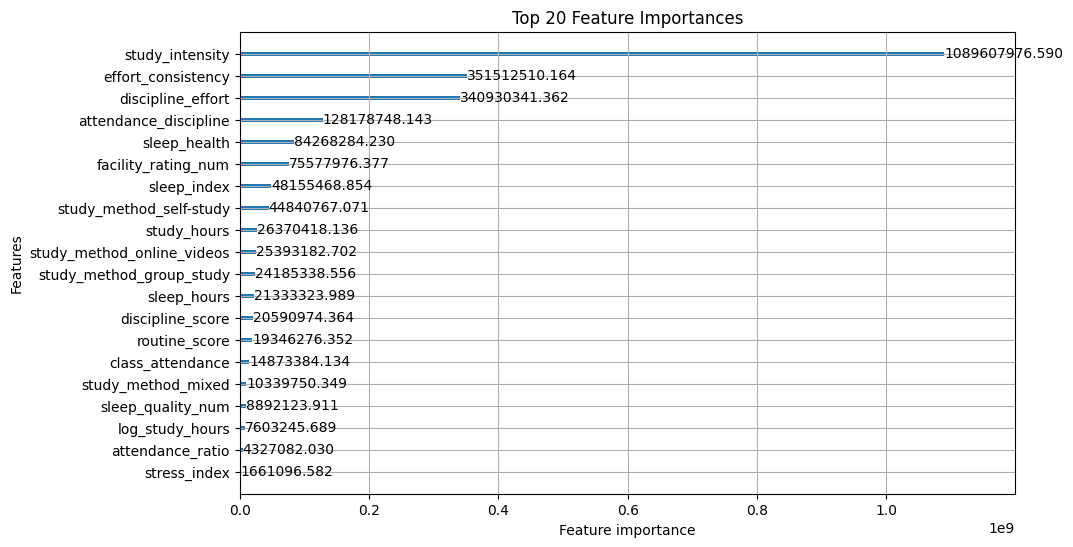

In [274]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Define the model
lgb_model = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.025,
    max_depth=5,               # ↓ slightly shallower
    num_leaves=24,             # ↓ better bias/variance tradeoff
    min_child_samples=120,     # ↑ VERY IMPORTANT (noise killer)
    subsample=0.65,
    subsample_freq=1,
    colsample_bytree=0.65,
    reg_alpha=0.8,
    reg_lambda=3.0,
    min_gain_to_split=0.01,    # ← STOP useless splits
    objective="regression",
    random_state=42,
    n_jobs=-1
)

# Train the model on the full dataset
lgb_model.fit(
    X,  # Your full feature matrix
    y,  # Your target vector (exam_score)
    eval_metric="rmse",  # Optional, will print warnings if no eval_set
    callbacks=[lgb.log_evaluation(period=0)]  # Suppress logs
)

# Predict on the same dataset (optional)
y_pred = lgb_model.predict(X)

# Evaluate performance on the full data (just for reference)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

print(f"Full data RMSE (just for reference): {rmse:.4f}")
print(f"Full data MAE (just for reference): {mae:.4f}")

# Feature importance (optional)
import matplotlib.pyplot as plt

lgb.plot_importance(lgb_model, max_num_features=20, importance_type='gain', figsize=(10,6))
plt.title("Top 20 Feature Importances")
plt.show()


In [153]:
df2_back.drop(columns=["source","exam_score"],inplace=True)

C:\Users\YASH PRABAKAR KATE\AppData\Local\Temp\ipykernel_22620\3804525146.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_back.drop(columns=["source","exam_score"],inplace=True)


In [287]:
X_test = df2_back

In [162]:
df2_back.shape

(270000, 27)

In [163]:
df2_back.columns

Index(['id', 'age', 'study_hours', 'class_attendance', 'sleep_hours',
       'sleep_quality_num', 'sleep_health', 'discipline_score',
       'effort_consistency', 'routine_score', 'log_study_hours',
       'attendance_sq', 'study_method_group study', 'study_method_mixed',
       'study_method_online videos', 'study_method_self-study', 'gender_male',
       'gender_other', 'course_b.sc', 'course_b.tech', 'course_ba',
       'course_bba', 'course_bca', 'course_diploma', 'internet_access_yes',
       'facility_rating_num', 'exam_score'],
      dtype='object')

In [168]:
X_test.columns

Index(['id', 'age', 'study_hours', 'class_attendance', 'sleep_hours',
       'sleep_quality_num', 'sleep_health', 'discipline_score',
       'effort_consistency', 'routine_score', 'log_study_hours',
       'attendance_sq', 'study_method_group study', 'study_method_mixed',
       'study_method_online videos', 'study_method_self-study', 'gender_male',
       'gender_other', 'course_b.sc', 'course_b.tech', 'course_ba',
       'course_bba', 'course_bca', 'course_diploma', 'internet_access_yes',
       'facility_rating_num', 'exam_score'],
      dtype='object')

In [169]:
X_test.drop(columns=["exam_score"],inplace=True)

C:\Users\YASH PRABAKAR KATE\AppData\Local\Temp\ipykernel_22620\2997591838.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.drop(columns=["exam_score"],inplace=True)


In [170]:
test_predictions = lgb_model.predict(X_test)

[LightGBM] [Warning] min_gain_to_split is set=0.01, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.01


In [ ]:
test_predictions = xgb_model.predict(X_test)

In [156]:
df2_back["exam_score"] = test_predictions
df2_back.head()

C:\Users\YASH PRABAKAR KATE\AppData\Local\Temp\ipykernel_22620\1252534222.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_back["exam_score"] = test_predictions


,id,age,study_hours,class_attendance,sleep_hours,sleep_quality_num,sleep_health,discipline_score,effort_consistency,routine_score,...,gender_other,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,internet_access_yes,facility_rating_num,exam_score
630000,630000,24,6.85,65.2,5.2,0,0.0000,3.0008,4.46620,32.60000,...,1,0,0,1,0,0,0,1,3,71.732091
630001,630001,18,6.61,45.0,9.3,0,0.0000,2.8240,2.97450,22.50000,...,0,0,0,0,0,0,1,0,1,70.239597
630002,630002,24,6.60,98.5,6.2,2,1.5500,3.0340,6.50100,50.02500,...,0,0,1,0,0,0,0,1,2,87.719383
630003,630003,24,3.03,66.3,5.7,1,0.7125,1.4772,2.00889,33.50625,...,0,0,0,0,0,0,1,1,2,56.623495
630004,630004,20,2.03,42.4,9.2,1,1.1500,0.9816,0.86072,21.77500,...,0,0,1,0,0,0,0,1,1,46.393926


In [157]:
df2_result = df2_back.loc[:, ["id", "exam_score"]]

In [71]:
df2_result.head()

,id,exam_score
id,,
630000,630000,71.193696
630001,630001,70.500259
630002,630002,88.031936
630003,630003,57.075282
630004,630004,46.453603


In [158]:
df2_result.to_csv("exam_score_predictions(12).csv", index=False)
print("Predictions saved successfully.")

Predictions saved successfully.


In [275]:
X = X[important_features]
y = df1_back["exam_score"]


In [276]:
import lightgbm as lgb

tabm_model = lgb.LGBMRegressor(
    n_estimators=2500,
    learning_rate=0.025,
    max_depth=5,
    num_leaves=24,
    min_child_samples=120,
    subsample=0.65,
    colsample_bytree=0.65,
    reg_alpha=0.8,
    reg_lambda=3.0,
    objective="regression",
    random_state=42,
    n_jobs=-1
)

tabm_model.fit(X, y)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009256 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3270
[LightGBM] [Info] Number of data points in the train set: 630000, number of used features: 22
[LightGBM] [Info] Start training from score 62.506672
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

LGBMRegressor(colsample_bytree=0.65, learning_rate=0.025, max_depth=5,
              min_child_samples=120, n_estimators=2500, n_jobs=-1,
              num_leaves=24, objective='regression', random_state=42,
              reg_alpha=0.8, reg_lambda=3.0, subsample=0.65)

In [288]:
import numpy as np
X_test = X_test[important_features]
test_preds_tabm = tabm_model.predict(X_test)


In [289]:
X_test.shape

(270000, 22)

In [290]:
low = np.percentile(test_preds_tabm, 10)
high = np.percentile(test_preds_tabm, 90)

mask = (test_preds_tabm >= low) & (test_preds_tabm <= high)

X_pseudo = X_test[mask]
y_pseudo = test_preds_tabm[mask]


In [291]:
import pandas as pd

X_aug = pd.concat([X, X_pseudo], axis=0)
y_aug = pd.concat([y, pd.Series(y_pseudo, index=X_pseudo.index)], axis=0)

sample_weight = np.concatenate([
    np.ones(len(y)),          # real labels
    np.full(len(y_pseudo), 0.3)  # pseudo labels (LOW weight)
])


In [292]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=4500,
    learning_rate=0.02,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.4,
    reg_lambda=2.5,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_aug,
    y_aug,
    sample_weight=sample_weight
)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.02, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=4500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [293]:
test_predictions = xgb_model.predict(X_test)

In [294]:
X_test.shape

(270000, 22)

In [285]:
test_predictions.shape

(94500,)

In [284]:
df2_back.shape

(270000, 36)

In [295]:
df2_back["exam_score"] = test_predictions
df2_back.head()

C:\Users\YASH PRABAKAR KATE\AppData\Local\Temp\ipykernel_22620\1252534222.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_back["exam_score"] = test_predictions


,id,age,study_hours,class_attendance,sleep_hours,exam_score,sleep_quality_num,sleep_health,discipline_score,effort_consistency,...,gender_male,gender_other,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,internet_access_yes,facility_rating_num
630000,630000,24,6.85,65.2,5.2,71.097282,0,0.0000,3.0008,4.46620,...,0,1,0,0,1,0,0,0,1,3
630001,630001,18,6.61,45.0,9.3,71.291916,0,0.0000,2.8240,2.97450,...,1,0,0,0,0,0,0,1,0,1
630002,630002,24,6.60,98.5,6.2,86.942810,2,1.5500,3.0340,6.50100,...,0,0,0,1,0,0,0,0,1,2
630003,630003,24,3.03,66.3,5.7,56.516735,1,0.7125,1.4772,2.00889,...,1,0,0,0,0,0,0,1,1,2
630004,630004,20,2.03,42.4,9.2,47.445045,1,1.1500,0.9816,0.86072,...,0,0,0,1,0,0,0,0,1,1


In [296]:
df2_result = df2_back.loc[:, ["id", "exam_score"]]

In [297]:
df2_result.to_csv("exam_score_predictions(15).csv", index=False)
print("Predictions saved successfully.")

Predictions saved successfully.
